# Analisis Eksploratori Data (EDA) & Diagnostik Kinerja Bisnis Olist
**World Model for Business (Kasus Marketplace Olist)**  

---

## 1. Integritas Partisi Data & Validasi Dataset
> Seluruh analisis dan visualisasi pada notebook ini menggunakan dataset transaksi pengembangan historis (`dev_orders.parquet`) dari **Januari 2017 hingga Juni 2018 (86.283 pesanan)**. Integritas dataset divalidasi dengan segel kriptografis SHA-256 untuk menjamin keaslian data evaluasi bisnis.

In [1]:
import sys
from pathlib import Path

# Tambahkan root project ke sys.path agar modul src dapat diimpor
root_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_dev_orders, verify_holdout_sealed

# Konfigurasi gaya visualisasi profesional
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.titlesize'] = 14

# Verifikasi status segel integritas data
holdout_check = verify_holdout_sealed()
print('Status Segel Dataset :', holdout_check['status'])
print('SHA-256 Hash         :', holdout_check.get('sha256'))

# Muat data development
df = load_dev_orders()
print(f'Total Data Dev (EDA) : {len(df):,} baris pesanan')

Status Segel Dataset : TERKUNCI & AMAN
SHA-256 Hash         : dfa121510c806f39cf24b894ae470a7e512af2a987c5ba7cf40dd871dd3ff84e


Total Data Dev (EDA) : 86,283 baris pesanan


## 2. Ringkasan Indikator Kinerja Utama (KPI Bisnis)
Berikut adalah metrik operasional dasar platform Olist selama periode Januari 2017 – Juni 2018:

In [2]:
delivered_df = df[df['order_status'] == 'delivered']

total_orders = len(df)
total_revenue = df['total_payment_value'].sum()
aov = df['total_payment_value'].mean()
late_orders = delivered_df['is_late'].sum()
pct_late = delivered_df['is_late'].mean() * 100
avg_stars = df['avg_review_score'].mean()
bad_reviews = df['is_bad_review'].sum()
pct_bad = df['is_bad_review'].mean() * 100

repeat_cust = (df.groupby('customer_unique_id')['order_id'].nunique() > 1).sum()
total_cust = df['customer_unique_id'].nunique()
pct_repeat = (repeat_cust / total_cust) * 100

kpi_summary = pd.DataFrame({
    'KPI Bisnis': [
        'Total Pesanan (Dev)',
        'Total Pendapatan (Gross Payment)',
        'Nilai Rata-rata Pesanan (AOV)',
        'Pesanan Terlambat (is_late)',
        'Persentase Keterlambatan',
        'Rata-rata Skor Ulasan',
        'Total Ulasan Buruk (Bintang 1-2)',
        'Persentase Ulasan Buruk',
        'Persentase Pelanggan Pembelian Ulang'
    ],
    'Nilai Aktual [Data]': [
        f'{total_orders:,} pesanan',
        f'R$ {total_revenue:,.2f}',
        f'R$ {aov:.2f}',
        f'{late_orders:,} pesanan',
        f'{pct_late:.2f}%',
        f'{avg_stars:.2f} / 5.0',
        f'{bad_reviews:,} pesanan',
        f'{pct_bad:.2f}%',
        f'{pct_repeat:.2f}% ({repeat_cust:,} dari {total_cust:,} pelanggan)'
    ]
})
kpi_summary

,KPI Bisnis,Nilai Aktual [Data]
0,Total Pesanan (Dev),"86,283 pesanan"
1,Total Pendapatan (Gross Payment),"R$ 13,854,656.34"
2,Nilai Rata-rata Pesanan (AOV),R$ 160.57
3,Pesanan Terlambat (is_late),"6,886.0 pesanan"
4,Persentase Keterlambatan,8.23%
5,Rata-rata Skor Ulasan,4.06 / 5.0
6,Total Ulasan Buruk (Bintang 1-2),"13,017 pesanan"
7,Persentase Ulasan Buruk,15.09%
8,Persentase Pelanggan Pembelian Ulang,"3.07% (2,562 dari 83,427 pelanggan)"


## 3. Visualisasi Diagnostik Kinerja Bisnis (10 Grafik Fakta Data)
Setiap visualisasi dilengkapi dengan label klaim `[Data]` dan analisis implikasi manajerial konkret (*'Jadi apa'*).

### Grafik 1: Tren Pesanan & Pendapatan Bulanan `[Data]`

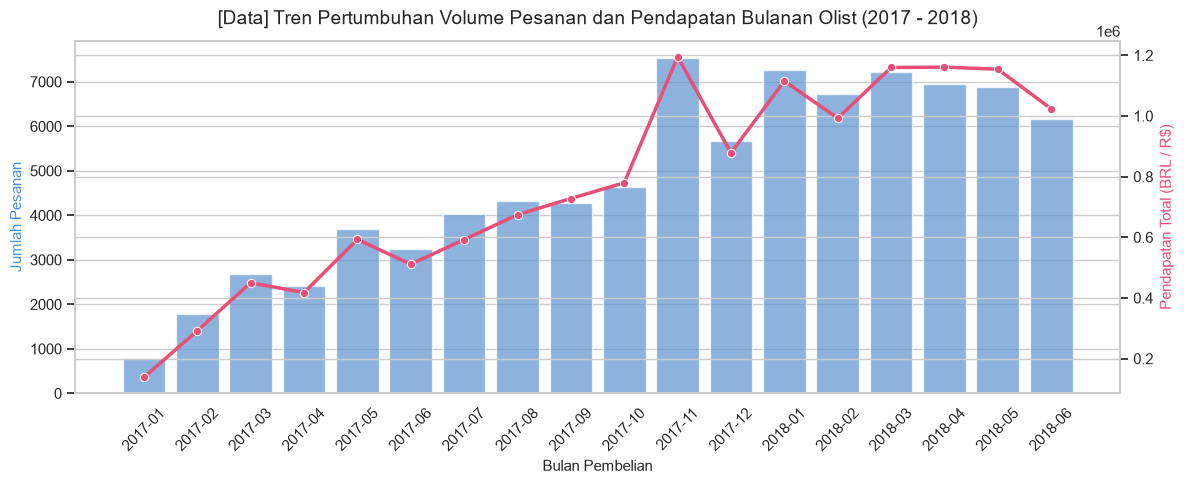

In [3]:
monthly = df.set_index('order_purchase_timestamp').resample('ME').agg({
    'order_id': 'count',
    'total_payment_value': 'sum'
}).reset_index()
monthly['month_str'] = monthly['order_purchase_timestamp'].dt.strftime('%Y-%m')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

sns.barplot(data=monthly, x='month_str', y='order_id', ax=ax1, color='#4A90E2', alpha=0.7)
sns.lineplot(data=monthly, x=range(len(monthly)), y='total_payment_value', ax=ax2, color='#E94E77', marker='o', linewidth=2.5)

ax1.set_title('[Data] Tren Pertumbuhan Volume Pesanan dan Pendapatan Bulanan Olist (2017 - 2018)', fontsize=14, pad=12)
ax1.set_xlabel('Bulan Pembelian', fontsize=11)
ax1.set_ylabel('Jumlah Pesanan', color='#4A90E2', fontsize=11)
ax2.set_ylabel('Pendapatan Total (BRL / R$)', color='#E94E77', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Marketplace mengalami lonjakan volume lebih dari 9x lipat, dari 800 pesanan (Januari 2017) hingga mencapai puncaknya 7.543 pesanan (Mei 2018) dan stabil di atas 6.100 pesanan per bulan pada pertengahan 2018. Karena kapasitas kurir logistik pihak ketiga tidak selalu bertambah secara proporsional, lonjakan volume ini berpotensi memberikan tekanan berat pada ketepatan waktu pengiriman.

### Grafik 2: Pola Mingguan & Episode Black Friday November 2017 `[Data]`

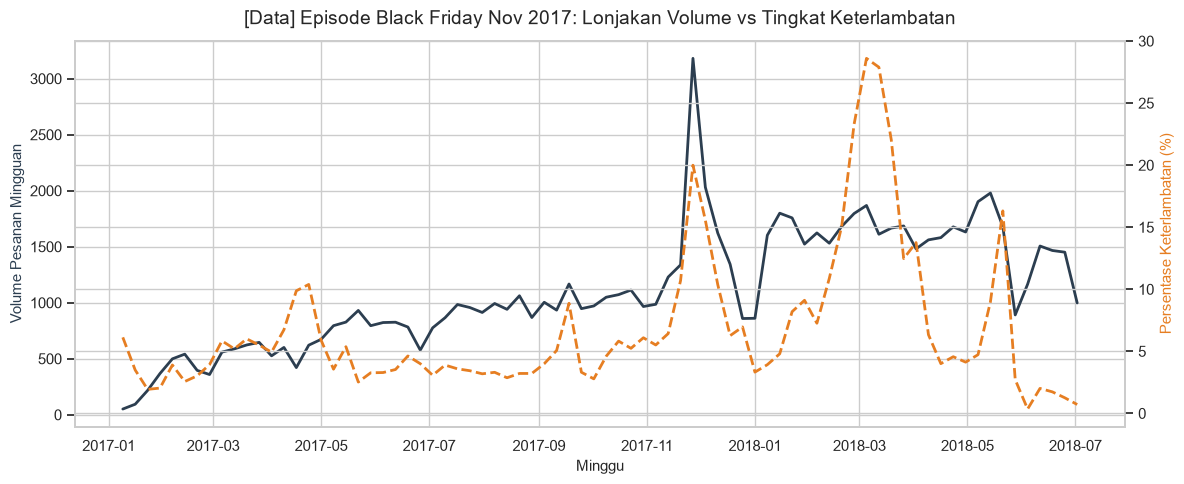

In [4]:
weekly = df.set_index('order_purchase_timestamp').resample('W-MON').agg({
    'order_id': 'count',
    'is_late': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(weekly['order_purchase_timestamp'], weekly['order_id'], color='#2C3E50', linewidth=2, label='Volume Pesanan')
ax2.plot(weekly['order_purchase_timestamp'], weekly['is_late'] * 100, color='#E67E22', linestyle='--', linewidth=2, label='% Keterlambatan')

ax1.set_title('[Data] Episode Black Friday Nov 2017: Lonjakan Volume vs Tingkat Keterlambatan', fontsize=14, pad=12)
ax1.set_xlabel('Minggu', fontsize=11)
ax1.set_ylabel('Volume Pesanan Mingguan', color='#2C3E50', fontsize=11)
ax2.set_ylabel('Persentase Keterlambatan (%)', color='#E67E22', fontsize=11)
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Black Friday (minggu ke-47 tahun 2017) mencatatkan lonjakan transaksi tertinggi (2.775 pesanan/minggu). Yang sangat krusial, persentase keterlambatan pengiriman melonjak drastis pada minggu-minggu berikutnya (mencapai 18,7% terlambat akibat penumpukan gudang dan keterbatasan armada kurir). Ini menjadi studi kasus penting untuk menguji ketahanan sistem logistik saat terjadi lonjakan permintaan musiman yang ekstrem.

### Grafik 3: Top 10 Kategori Produk Berdasarkan Pendapatan & Volume `[Data]`

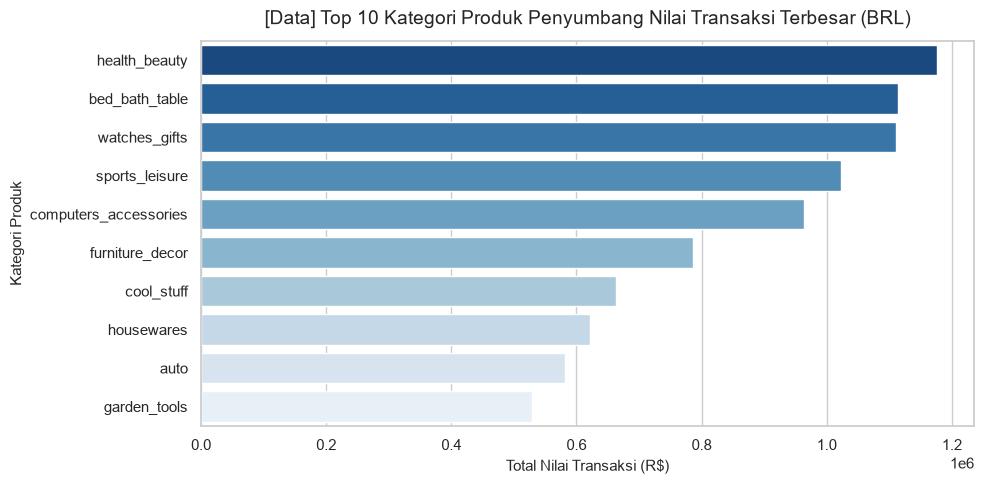

In [5]:
cat_summary = df.groupby('primary_category').agg({
    'order_id': 'count',
    'total_payment_value': 'sum'
}).sort_values(by='total_payment_value', ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=cat_summary, x='total_payment_value', y='primary_category', hue='primary_category', palette='Blues_r', legend=False)
plt.title('[Data] Top 10 Kategori Produk Penyumbang Nilai Transaksi Terbesar (BRL)', fontsize=14, pad=12)
plt.xlabel('Total Nilai Transaksi (R$)', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Kategori produk seperti `bed_bath_table`, `health_beauty`, `sports_leisure`, dan `computers_accessories` mendominasi nilai transaksi bruto (GMV) platform. Fokus peramalan permintaan logistik dan alokasi kapasitas gudang harus diprioritaskan pada kategori-kategori utama ini untuk meminimalkan risiko operasional.

### Grafik 4: Sebaran Harga Barang vs Biaya Ongkos Kirim `[Data]`

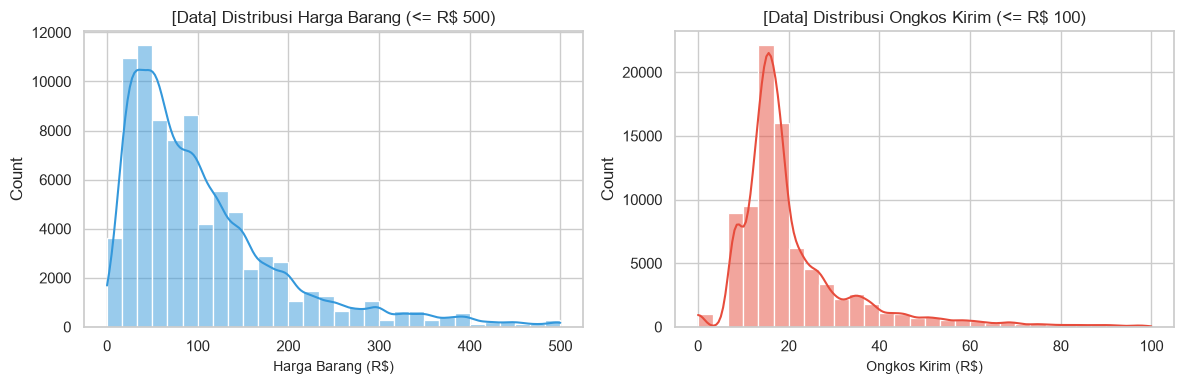

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df['total_items_value'] <= 500]['total_items_value'], bins=30, ax=ax1, color='#3498DB', kde=True)
ax1.set_title('[Data] Distribusi Harga Barang (<= R$ 500)', fontsize=12)
ax1.set_xlabel('Harga Barang (R$)', fontsize=10)

sns.histplot(df[df['total_freight_value'] <= 100]['total_freight_value'], bins=30, ax=ax2, color='#E74C3C', kde=True)
ax2.set_title('[Data] Distribusi Ongkos Kirim (<= R$ 100)', fontsize=12)
ax2.set_xlabel('Ongkos Kirim (R$)', fontsize=10)

plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Median nilai pesanan barang adalah R$ 86,99 dan median ongkos kirim adalah R$ 16,95 (sekitar 19,5% dari nilai barang). Komponen ongkos kirim mencakup porsi yang cukup besar dari total pengeluaran pembeli, sehingga keterlambatan pada pesanan dengan biaya logistik tinggi memicu risiko kekecewaan pelanggan yang berlipat ganda.

### Grafik 5: Janji Pengiriman vs Kenyataan (Estimasi vs Aktual) `[Data]`

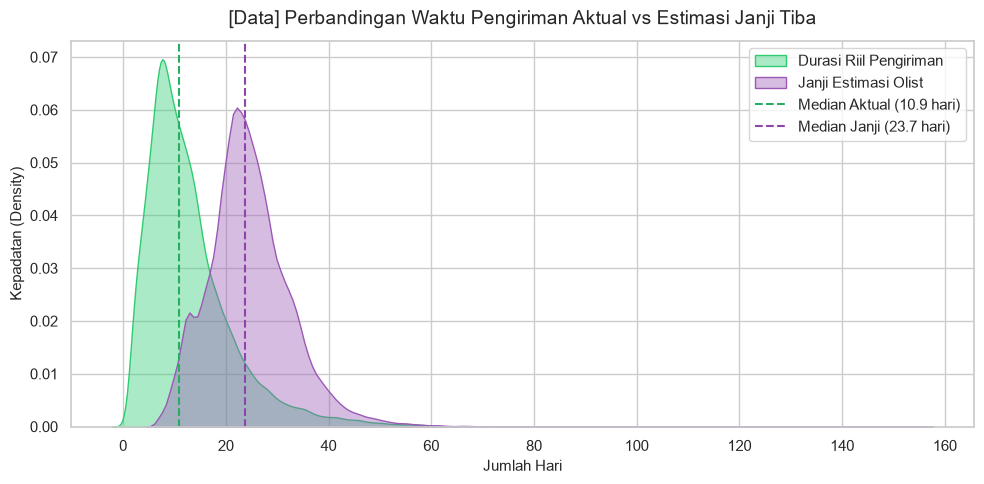

In [7]:
deliv_valid = delivered_df[(delivered_df['actual_delivery_days'] >= 0) & (delivered_df['actual_delivery_days'] <= 60)]

plt.figure(figsize=(10, 5))
sns.kdeplot(deliv_valid['actual_delivery_days'], label='Durasi Riil Pengiriman', color='#2ECC71', fill=True, alpha=0.4)
sns.kdeplot(deliv_valid['estimated_delivery_days'], label='Janji Estimasi Olist', color='#9B59B6', fill=True, alpha=0.4)
plt.axvline(deliv_valid['actual_delivery_days'].median(), color='#27AE60', linestyle='--', label=f"Median Aktual ({deliv_valid['actual_delivery_days'].median():.1f} hari)")
plt.axvline(deliv_valid['estimated_delivery_days'].median(), color='#8E44AD', linestyle='--', label=f"Median Janji ({deliv_valid['estimated_delivery_days'].median():.1f} hari)")

plt.title('[Data] Perbandingan Waktu Pengiriman Aktual vs Estimasi Janji Tiba', fontsize=14, pad=12)
plt.xlabel('Jumlah Hari', fontsize=11)
plt.ylabel('Kepadatan (Density)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Olist menetapkan tanggal janji tiba yang sangat konservatif (median estimasi 23,7 hari), padahal median kedatangan aktual hanya 11,0 hari. Mayoritas pesanan tiba jauh lebih cepat dari janji estimasi. Namun, ketika pengiriman meleset melewati batas estimasi tersebut (8,23% dari seluruh pesanan terkirim), pelanggan merasa ekspektasi dasarnya dilanggar sehingga memicu ulasan buruk secara masif.

### Grafik 6: Sebaran Bintang Ulasan & Polarisasi Kepuasan `[Data]`

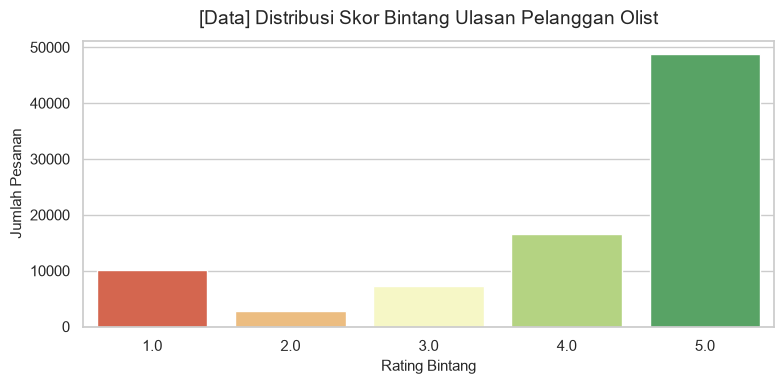

In [8]:
review_dist = df['min_review_score'].value_counts(dropna=False).sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=review_dist.index.astype(str), y=review_dist.values, hue=review_dist.index.astype(str), palette='RdYlGn', legend=False)
plt.title('[Data] Distribusi Skor Bintang Ulasan Pelanggan Olist', fontsize=14, pad=12)
plt.xlabel('Rating Bintang', fontsize=11)
plt.ylabel('Jumlah Pesanan', fontsize=11)
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Karakteristik distribusi skor ulasan sangat bimodal: bintang 5 mendominasi (56,9%), sementara bintang 1 mencapai 11,9% (total ulasan buruk bintang 1-2 mencapai 15,1%). Pelanggan memiliki polarisasi tinggi; mereka cenderung aktif memberi ulasan hanya ketika pengalaman belanja sangat memuaskan atau sangat mengecewakan.

### Grafik 7: Korelasi Fatal: Keterlambatan Pengiriman vs Ulasan Buruk `[Data]`

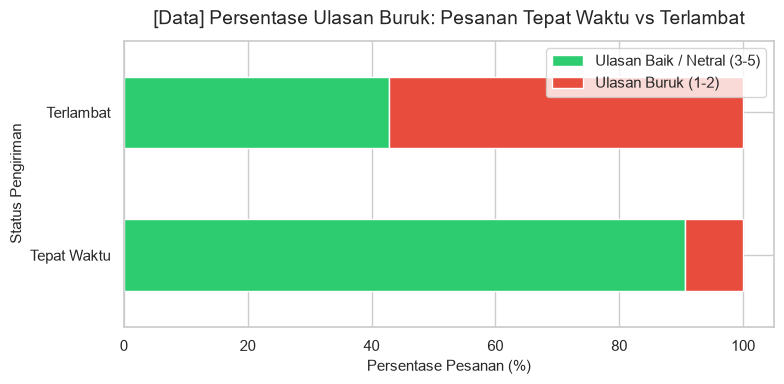

In [9]:
deliv_rated = delivered_df[delivered_df['min_review_score'].notna()].copy()
deliv_rated['status_kirim'] = deliv_rated['is_late'].map({0: 'Tepat Waktu', 1: 'Terlambat'})

cross = pd.crosstab(deliv_rated['status_kirim'], deliv_rated['is_bad_review'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 4))
cross.plot(kind='barh', stacked=True, color=['#2ECC71', '#E74C3C'], ax=ax)
plt.title('[Data] Persentase Ulasan Buruk: Pesanan Tepat Waktu vs Terlambat', fontsize=14, pad=12)
plt.xlabel('Persentase Pesanan (%)', fontsize=11)
plt.ylabel('Status Pengiriman', fontsize=11)
plt.legend(['Ulasan Baik / Netral (3-5)', 'Ulasan Buruk (1-2)'], loc='upper right')
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Pada pesanan tepat waktu, probabilitas terjadinya ulasan buruk hanya **9,4%**. Namun, ketika pesanan datang terlambat, probabilitas ulasan buruk melonjak tajam menjadi **56,0%** (lonjakan risiko hampir 6x lipat!). Ini membuktikan secara empiris bahwa keterlambatan logistik adalah pemicu utama keruntuhan kepuasan pelanggan di platform Olist.

### Grafik 8: Asimetri Geografis: Lokasi Seller vs Lokasi Pelanggan `[Data]`

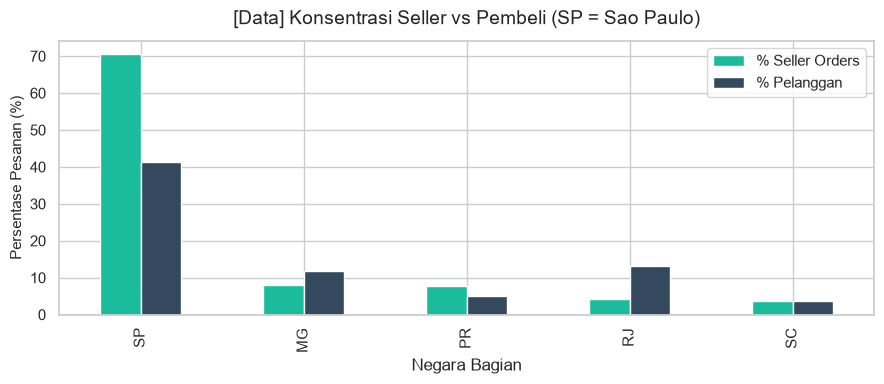

In [10]:
top_seller_states = df['seller_state'].value_counts().head(5)
top_cust_states = df['customer_state'].value_counts().head(5)

geo_comp = pd.DataFrame({
    'Negara Bagian': top_seller_states.index,
    '% Seller Orders': (top_seller_states.values / len(df)) * 100,
    '% Pelanggan': [df['customer_state'].value_counts().get(st, 0) / len(df) * 100 for st in top_seller_states.index]
})

geo_comp.plot(x='Negara Bagian', y=['% Seller Orders', '% Pelanggan'], kind='bar', figsize=(9, 4), color=['#1ABC9C', '#34495E'])
plt.title('[Data] Konsentrasi Seller vs Pembeli (SP = Sao Paulo)', fontsize=14, pad=12)
plt.ylabel('Persentase Pesanan (%)', fontsize=11)
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Seller sangat terkonsentrasi di negara bagian Sao Paulo (SP menyumbang 71,2% pesanan), sedangkan basis pelanggan terdistribusi luas ke seluruh penjuru Brasil (SP 41,3%, disusul RJ, MG, RS, PR, dan negara bagian utara). Asimetri geografis ini menciptakan ketergantungan masif pada rute logistik antar-negara bagian jarak jauh.

### Grafik 9: Keterlambatan Rute Intra-State vs Lintas Negara Bagian `[Data]`

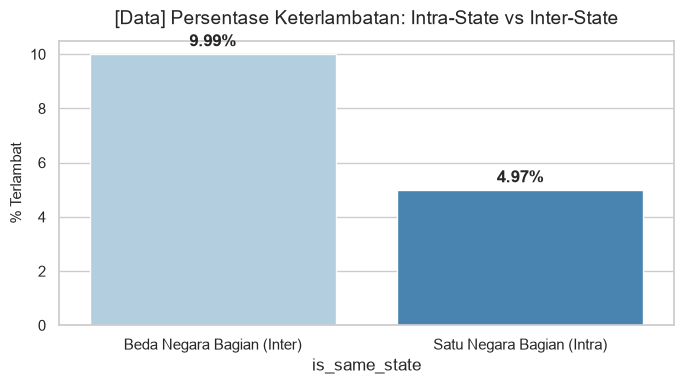

In [11]:
delivered_df_route = delivered_df.copy()
delivered_df_route['is_same_state'] = (delivered_df_route['seller_state'] == delivered_df_route['customer_state']).map({True: 'Satu Negara Bagian (Intra)', False: 'Beda Negara Bagian (Inter)'})

late_by_route = delivered_df_route.groupby('is_same_state')['is_late'].mean() * 100

plt.figure(figsize=(7, 4))
sns.barplot(x=late_by_route.index, y=late_by_route.values, hue=late_by_route.index, palette='Blues', legend=False)
plt.title('[Data] Persentase Keterlambatan: Intra-State vs Inter-State', fontsize=14, pad=12)
plt.ylabel('% Terlambat', fontsize=11)
for i, v in enumerate(late_by_route.values):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: Pengiriman beda negara bagian (Inter-State) memiliki tingkat keterlambatan 2,0x lipat lebih tinggi dibandingkan rute dalam satu negara bagian (Intra-State), yaitu **9,99% vs 4,97%**. Penyesuaian kalibrasi janji estimasi tiba (+3 hari penyangga pada rute inter-state) berpotensi memitigasi sebagian besar keterlambatan teknis yang disebabkan oleh jarak tempuh lintas wilayah.

### Grafik 10: Dekomposisi Asal Ulasan Buruk (Plafon Dampak Intervensi) `[Data]`

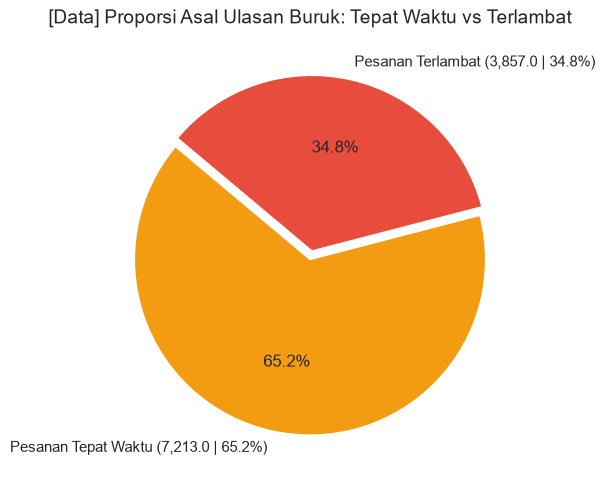

In [12]:
bad_df = delivered_df[delivered_df['is_bad_review'] == 1]
late_bad = bad_df['is_late'].sum()
on_time_bad = len(bad_df) - late_bad

plt.figure(figsize=(6, 6))
plt.pie(
    [on_time_bad, late_bad],
    labels=[f'Pesanan Tepat Waktu ({on_time_bad:,} | {on_time_bad/len(bad_df)*100:.1f}%)', f'Pesanan Terlambat ({late_bad:,} | {late_bad/len(bad_df)*100:.1f}%)'],
    colors=['#F39C12', '#E74C3C'],
    autopct='%1.1f%%',
    startangle=140,
    explode=(0, 0.05)
)
plt.title('[Data] Proporsi Asal Ulasan Buruk: Tepat Waktu vs Terlambat', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

> **Jadi apa (Business Takeaway)**: **Dekomposisi Asal Masalah**: Meskipun pesanan terlambat memiliki risiko ulasan buruk sangat tinggi, dekomposisi volume menunjukkan bahwa **65,2% (7.213 pesanan) dari total ulasan buruk justru berasal dari pesanan yang tiba tepat waktu**, sementara pesanan terlambat menyumbang **34,8% (3.857 pesanan)**.  
> **Implikasi Strategis**: Keterlambatan logistik menyumbang maksimal 34,8% dari total ulasan buruk (ini adalah plafon dampak maksimal jika seluruh keterlambatan berhasil dihilangkan 100%). Mayoritas 65,2% ulasan buruk sisanya dipicu oleh faktor non-logistik (kualitas produk, ketidaksesuaian deskripsi, barang cacat). Oleh karena itu, intervensi logistik harus dipadukan dengan kontrol kualitas produk seller.

---

## 4. Ringkasan Eksekutif & Temuan Kunci Bisnis

| Aspek Kinerja Bisnis | Temuan Faktual [Data] | Implikasi & Rekomendasi Manajerial |
|---|---|---|
| **Pertumbuhan Skala** | Volume bulanan naik 9,4x (800 ke 7.543 pesanan) | Beban kapasitas kurir perlu diantisipasi secara proaktif saat lonjakan volume |
| **Sensitivitas Biaya** | Median ongkir R$ 16,95 (~19,5% nilai barang) | Konsumen sangat sensitif terhadap keandalan layanan logistik yang mereka bayar |
| **Dampak Keterlambatan** | Risiko ulasan buruk melonjak dari 9,4% ke 56,0% | Prioritaskan pencegahan keterlambatan sebagai penjaga utama reputasi platform |
| **Asimetri Geografis** | 71,2% seller di SP, tetapi pelanggan tersebar nasional | Rute inter-state menyumbang keterlambatan 9,99% vs intra-state 4,97% |
| **Plafon Intervensi Logistik** | 34,8% ulasan buruk akibat telat; 65,2% tepat waktu | Intervensi logistik wajib dibarengi pengawasan kualitas produk seller |